# Analyse & Comparaison des configurations de minutes — v2

## Bibliothèques

In [37]:
#Load la data 
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

#modèles
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


from sklearn.model_selection import cross_val_score, train_test_split, learning_curve
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, silhouette_score
from sklearn.base import clone


from sklearn.calibration import calibration_curve

from scipy.stats import gaussian_kde

from sklearn.model_selection import GridSearchCV #test automatiquement toutes les combinaisons de paramètres (chercher pour knn)


## Chargement des CSV + définition des modèles

In [38]:
#https://docs.python.org/3/library/glob.html
csv_files = sorted(glob.glob("matchs_preprocessed_*.csv"))

if not csv_files:
    csv_files = sorted(glob.glob("matchs_preprocessed_*"))
    csv_files = [f for f in csv_files if "." not in f.split("matchs_preprocessed_")[-1]]

print(f"{len(csv_files)} fichier(s) trouvé(s) :")
for f in csv_files:
    print(f"-{f}")

model_defs = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "LR + PCA(95%)": Pipeline([("pca", PCA(n_components=0.95)), ("model", LogisticRegression(max_iter=1000))]),
    "KNN": KNeighborsClassifier(n_neighbors=600), #valeur trouvée dans une des étapes qui va suivre
    "Gaussian NB": GaussianNB(),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}

def make_pipeline(model):
    return Pipeline([
        ("imputer",SimpleImputer(strategy="median")),
        ("scaler",StandardScaler()),
        ("model",clone(model)), #on clone ici pour ne pas utiliser le même objet mémorisé 
    ])


10 fichier(s) trouvé(s) :
-matchs_preprocessed_10.csv
-matchs_preprocessed_10_15.csv
-matchs_preprocessed_10_15_20.csv
-matchs_preprocessed_10_15_20_25.csv
-matchs_preprocessed_10_20.csv
-matchs_preprocessed_15.csv
-matchs_preprocessed_15_20.csv
-matchs_preprocessed_20.csv
-matchs_preprocessed_25.csv
-matchs_preprocessed_5.csv


## Équilibre des classes

Vérification que le dataset n'est pas déséquilibré (autant de victoires que de défaites) pour chaque configuration.

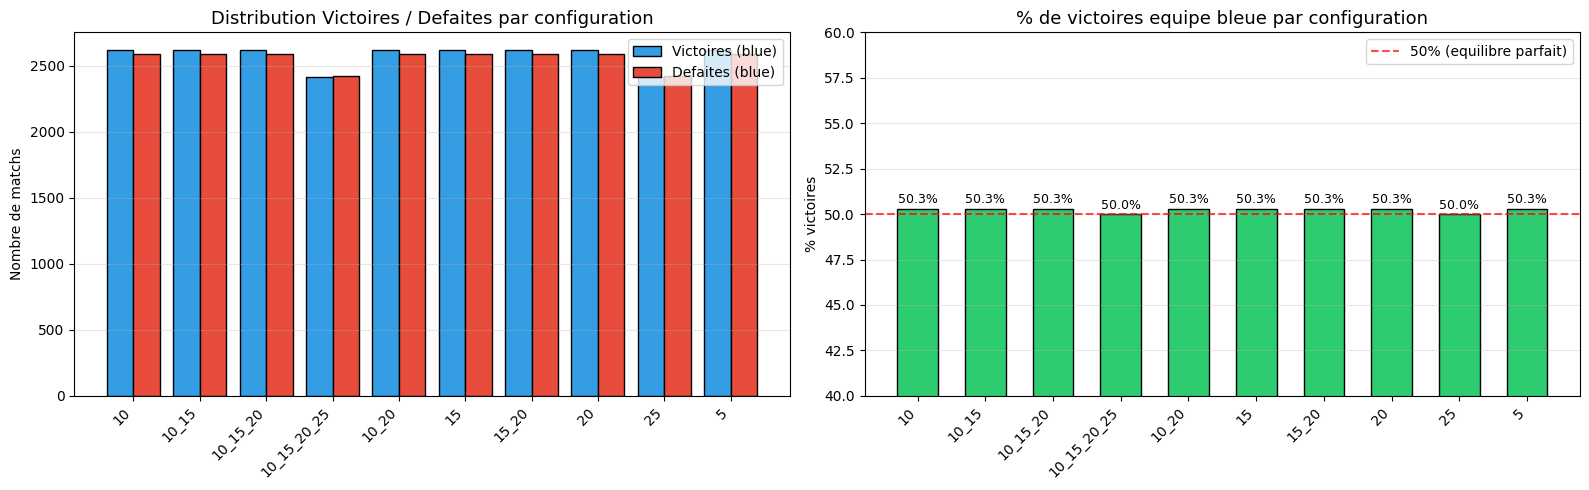


--- Résumé ---
     config  wins  losses  total  pct_win
         10  2623    2590   5213     50.3
      10_15  2623    2590   5213     50.3
   10_15_20  2623    2590   5213     50.3
10_15_20_25  2419    2421   4840     50.0
      10_20  2623    2590   5213     50.3
         15  2623    2590   5213     50.3
      15_20  2623    2590   5213     50.3
         20  2623    2590   5213     50.3
         25  2419    2421   4840     50.0
          5  2623    2590   5213     50.3


In [39]:
balance_rows = []
for csv_path in csv_files:
    config_name = csv_path.replace("matchs_preprocessed_", "").replace(".csv", "")
    df = pd.read_csv(csv_path, index_col=0)
    if "win" not in df.columns:
        continue
    counts = df["win"].value_counts()
    n_win  = counts.get(1, 0)
    n_loss = counts.get(0, 0)
    total  = n_win + n_loss
    balance_rows.append({
        "config" : config_name,
        "wins"   : n_win,
        "losses" : n_loss,
        "total"  : total,
        "pct_win": round(100 * n_win / total, 1) if total > 0 else 0,
    })

balance_df = pd.DataFrame(balance_rows).sort_values("config")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(len(balance_df))
w = 0.4
axes[0].bar(x-w/2, balance_df["wins"],width=w, label="Victoires (blue)",color="#359de3", edgecolor="black")
axes[0].bar(x+w/2, balance_df["losses"],width=w, label="Defaites (blue)",color="#e74c3c", edgecolor="black")
axes[0].set_xticks(x)
axes[0].set_xticklabels(balance_df["config"], rotation=45, ha="right")
axes[0].set_title("Distribution Victoires / Defaites par configuration", fontsize=13)
axes[0].set_ylabel("Nombre de matchs")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

colors_bar = ["#2ecc71" if abs(p - 50) < 3 else "#e67e22" for p in balance_df["pct_win"]]
bars = axes[1].bar(x, balance_df["pct_win"], color=colors_bar, edgecolor="black", width=0.6)
axes[1].axhline(50, color="red", linestyle="--", alpha=0.7, label="50% (equilibre parfait)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(balance_df["config"], rotation=45, ha="right")
axes[1].set_title("% de victoires equipe bleue par configuration", fontsize=13)
axes[1].set_ylabel("% victoires")
axes[1].set_ylim(40, 60)
axes[1].legend()
for bar, val in zip(bars, balance_df["pct_win"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3, f"{val}%", ha="center", fontsize=9)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\n--- Résumé ---")
print(balance_df[["config", "wins", "losses", "total", "pct_win"]].to_string(index=False))


## Évaluation sur chaque configuration

In [40]:
results= []
cv_scores_all= []
fitted_pipes= {}
test_sets = {}

for csv_path in csv_files:
    config_name = csv_path.replace("matchs_preprocessed_", "").replace(".csv", "")

    df = pd.read_csv(csv_path, index_col=0)
    if "win" not in df.columns:
        print(f"[SKIP] Colonne 'win' absente dans {csv_path}")
        continue

    feature_cols = [c for c in df.select_dtypes(include="number").columns if c != "win"]
    X = df[feature_cols]
    y = df["win"].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y #80, 20
    )

    fitted_pipes[config_name] = {}
    test_sets[config_name] = (X_test, y_test)

    for model_name, model in model_defs.items():
        pipe =make_pipeline(model)
        cv_scores = cross_val_score(pipe,X_train, y_train, cv=5,scoring="roc_auc")
        cv_auc= cv_scores.mean()
        pipe.fit(X_train, y_train)
        acc =accuracy_score(y_test,pipe.predict(X_test))
        auc= roc_auc_score(y_test,pipe.predict_proba(X_test)[:, 1])
        fitted_pipes[config_name][model_name] =pipe

        for fold_auc in cv_scores:
            cv_scores_all.append({"config": config_name, "model": model_name, "fold_auc": round(float(fold_auc), 3)})

        results.append({
            "config": config_name,
            "model" : model_name,
            "cv_auc": round(cv_auc, 3),
            "test_acc": round(acc, 3),
            "test_auc": round(auc, 3),
            "n_features":len(feature_cols),
        })
        print(f"[{config_name:<15}] {model_name:<22} cv_auc={cv_auc:.3f}  test_acc={acc:.3f}  test_auc={auc:.3f}")

results_df= pd.DataFrame(results)
cv_scores_df=pd.DataFrame(cv_scores_all)

print("\n── TOP 10 PIPELINES ──")
print(results_df.sort_values("test_auc", ascending=False).head(10).to_string(index=False))


[10             ] LogisticRegression     cv_auc=0.769  test_acc=0.635  test_auc=0.690
[10             ] LR + PCA(95%)          cv_auc=0.769  test_acc=0.626  test_auc=0.684
[10             ] KNN                    cv_auc=0.714  test_acc=0.643  test_auc=0.685
[10             ] Gaussian NB            cv_auc=0.680  test_acc=0.647  test_auc=0.674
[10             ] RandomForest           cv_auc=0.915  test_acc=0.819  test_auc=0.920
[10             ] GradientBoosting       cv_auc=0.821  test_acc=0.691  test_auc=0.769
[10_15          ] LogisticRegression     cv_auc=0.808  test_acc=0.663  test_auc=0.743
[10_15          ] LR + PCA(95%)          cv_auc=0.808  test_acc=0.677  test_auc=0.741
[10_15          ] KNN                    cv_auc=0.750  test_acc=0.678  test_auc=0.730
[10_15          ] Gaussian NB            cv_auc=0.722  test_acc=0.678  test_auc=0.716
[10_15          ] RandomForest           cv_auc=0.926  test_acc=0.849  test_auc=0.938
[10_15          ] GradientBoosting       cv_auc=0.852 

Meilleure valeur n_neighbors pour knn 

In [41]:
knn_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   KNeighborsClassifier()),
])

param_grid = {
    "model__n_neighbors": [p for p in range(1, X_train.shape[0]*4//5, 100) if p % 2 != 0] #car cv =5 dans GridSearchCV
}

grid_search = GridSearchCV(knn_pipeline, param_grid, cv=5, scoring="accuracy")
grid_search.fit(X_train, y_train)

print("Meilleur k :", grid_search.best_params_)
print("Score :", grid_search.best_score_)

Meilleur k : {'model__n_neighbors': 1}
Score : 0.7479616306954437


## Heatmap de comparaison globale

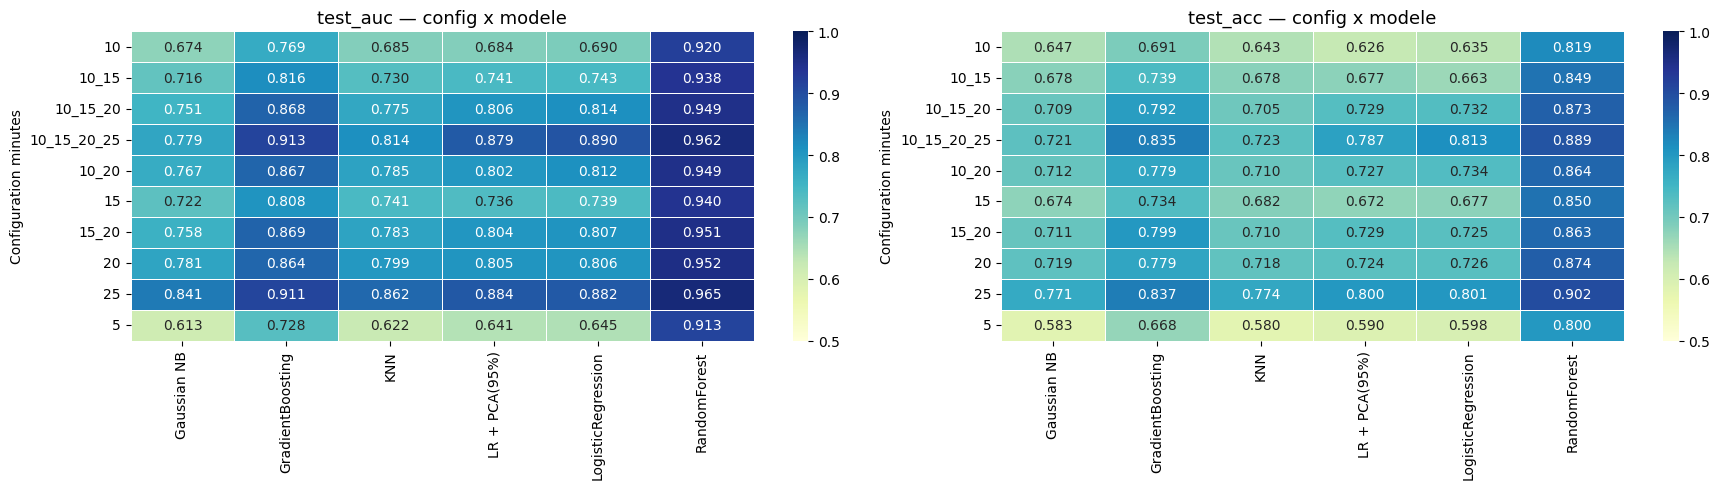

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, metric in zip(axes, ["test_auc", "test_acc"]):
    pivot = results_df.pivot(index="config", columns="model", values=metric)
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu",
                ax=ax, linewidths=0.5, vmin=0.5, vmax=1.0)
    ax.set_title(f"{metric} — config x modele", fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel("Configuration minutes")
plt.tight_layout()
plt.show()


---
## Analyses essentielles

### 1 — AUC en fonction de la minute (configs isolées)

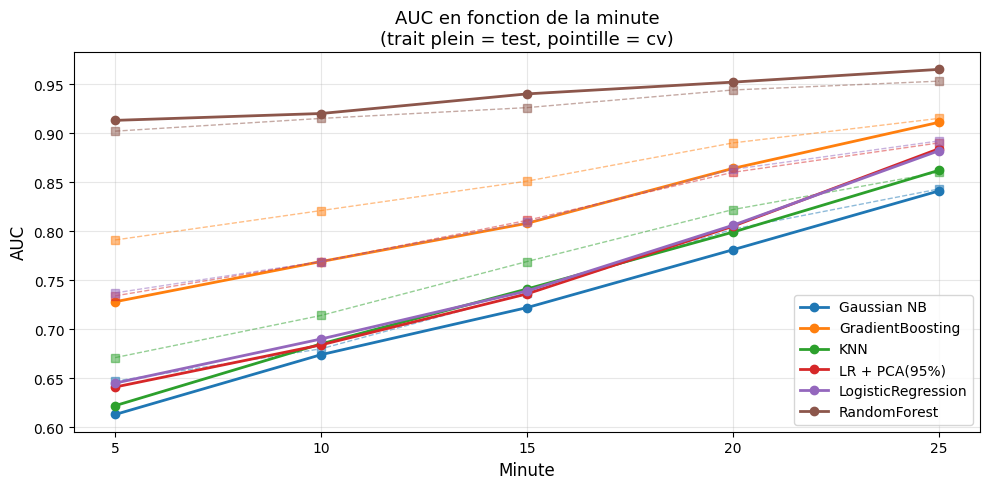

In [43]:
single_min_configs = ["5", "10", "15", "20", "25"]
df_single = results_df[results_df["config"].isin(single_min_configs)].copy()
df_single["minute"] = df_single["config"].astype(int)
df_single = df_single.sort_values("minute")

fig, ax = plt.subplots(figsize=(10, 5))
for model_name, grp in df_single.groupby("model"):
    grp = grp.sort_values("minute")
    ax.plot(grp["minute"], grp["test_auc"], marker="o",linewidth=2,label=model_name)
    ax.plot(grp["minute"], grp["cv_auc"], marker="s",linewidth=1,linestyle="--",alpha=0.5, color=ax.lines[-1].get_color())

ax.set_xlabel("Minute",fontsize=12)
ax.set_ylabel("AUC", fontsize=12)
ax.set_title("AUC en fonction de la minute\n(trait plein = test, pointille = cv)", fontsize=13)
ax.set_xticks([5, 10, 15, 20, 25])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 2 — Feature Importance (RandomForest) — Top 3 configs

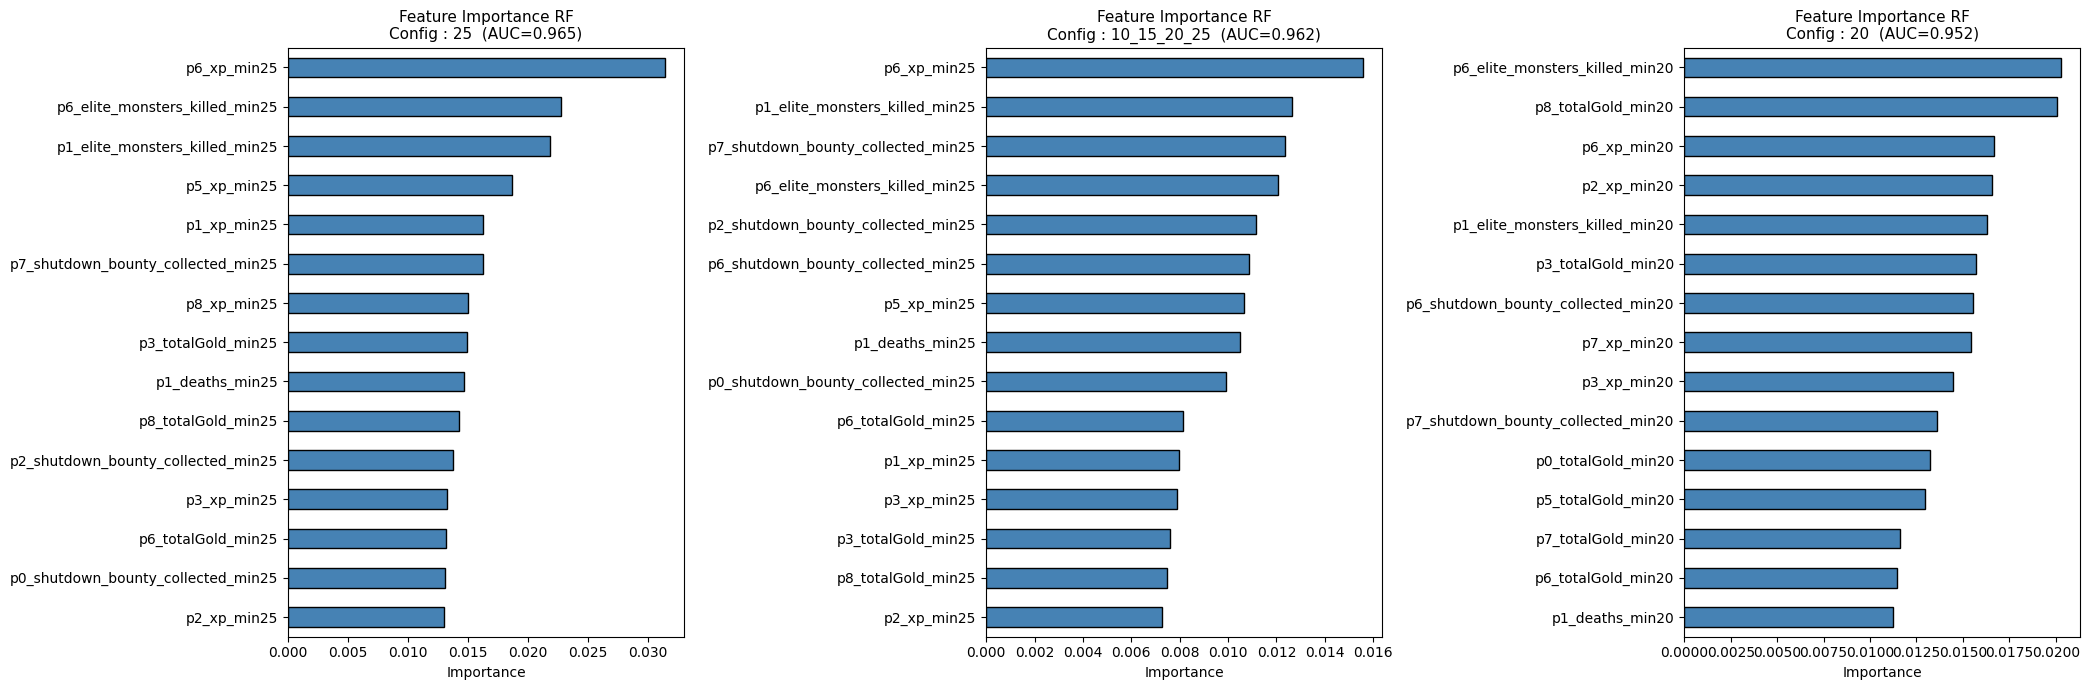

In [44]:
top_configs = (
    results_df[results_df["model"] == "RandomForest"]
    .sort_values("test_auc", ascending=False)
    .head(3)["config"].tolist()
)

fig, axes = plt.subplots(1, len(top_configs), figsize=(7 * len(top_configs), 7))
if len(top_configs) == 1:
    axes = [axes]

for ax, config in zip(axes, top_configs):
    pipe= fitted_pipes[config]["RandomForest"]
    rf =pipe.named_steps["model"]
    X_test, _=test_sets[config]
    imputer= pipe.named_steps["imputer"]
    if hasattr(imputer,"get_feature_names_out"):
        feature_names = list(imputer.get_feature_names_out())
    else:
        mask= ~np.isnan(imputer.statistics_)
        feature_names= np.array(X_test.columns.tolist())[mask].tolist()

    importances = (pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False).head(15).sort_values())

    importances.plot(kind="barh", ax=ax,color="steelblue", edgecolor="black")
    auc_val= results_df.query("config == @config and model == 'RandomForest'")["test_auc"].values[0]
    ax.set_title(f"Feature Importance RF\nConfig : {config}  (AUC={auc_val:.3f})", fontsize=11)
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()


### 3 — Courbes ROC superposées (meilleur modèle)

Meilleur modele moyen :RandomForest


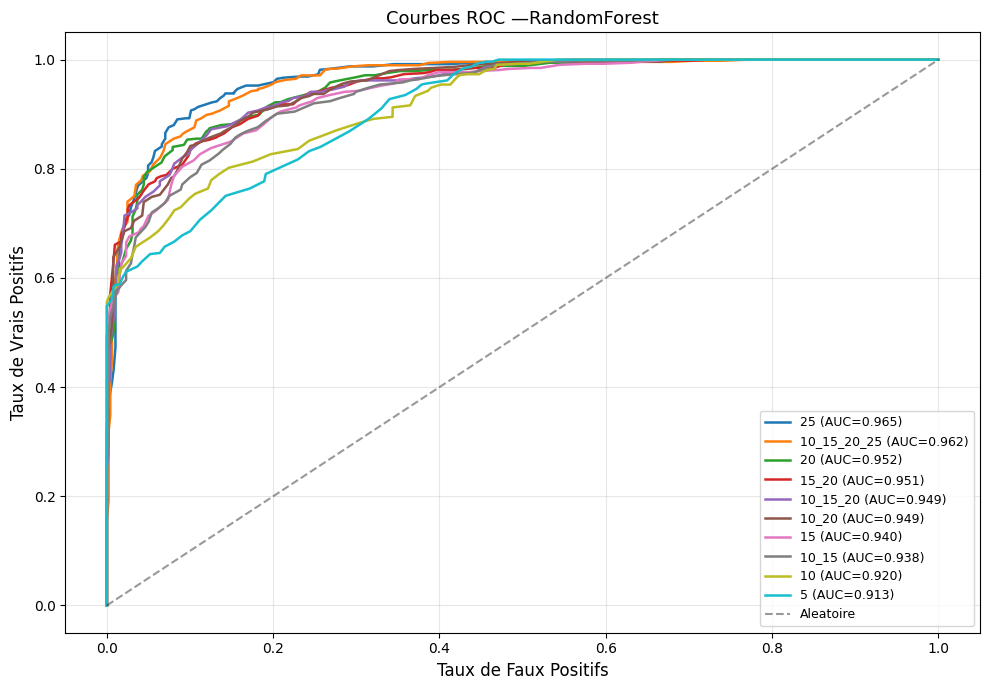

In [45]:
best_model = results_df.groupby("model")["test_auc"].mean().idxmax()
print(f"Meilleur modele moyen :{best_model}")

fig, ax = plt.subplots(figsize=(10, 7))
configs_sorted = (results_df[results_df["model"] == best_model].sort_values("test_auc", ascending=False)["config"].tolist()
)

for config in configs_sorted:
    if best_model not in fitted_pipes.get(config, {}):
        continue
    pipe= fitted_pipes[config][best_model]
    X_test, y_test= test_sets[config]
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val= roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, linewidth=1.8, label=f"{config} (AUC={auc_val:.3f})")

ax.plot([0, 1],[0, 1],"k--",alpha=0.4,label="Aleatoire")
ax.set_xlabel("Taux de Faux Positifs",fontsize=12)
ax.set_ylabel("Taux de Vrais Positifs",fontsize=12)
ax.set_title(f"Courbes ROC —{best_model}",fontsize=13)
ax.legend(loc="lower right",fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Analyses de robustesse

### Boxplot de la variance CV par config

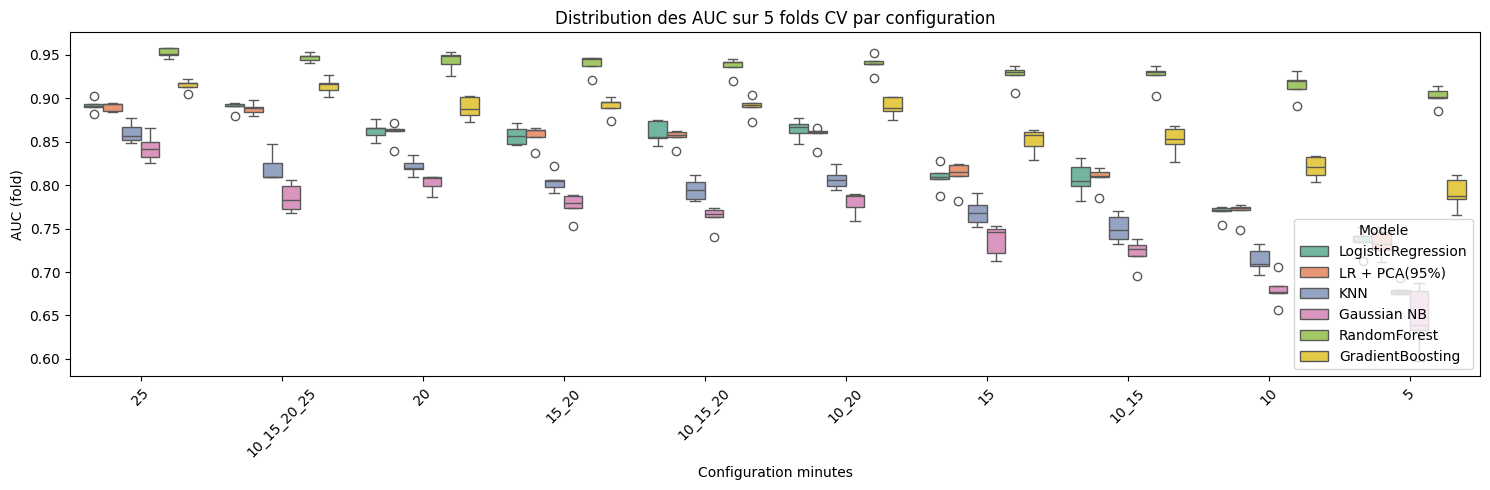

In [46]:
configs_order = (
    results_df.groupby("config")["test_auc"].max()
    .sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(data=cv_scores_df, x="config", y="fold_auc", hue="model",order=configs_order, ax=ax, palette="Set2")
ax.set_title("Distribution des AUC sur 5 folds CV par configuration", fontsize=12)
ax.set_xlabel("Configuration minutes")
ax.set_ylabel("AUC (fold)")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Modele",loc="lower right")
plt.tight_layout()
plt.show()


### AUC vs nombre de features

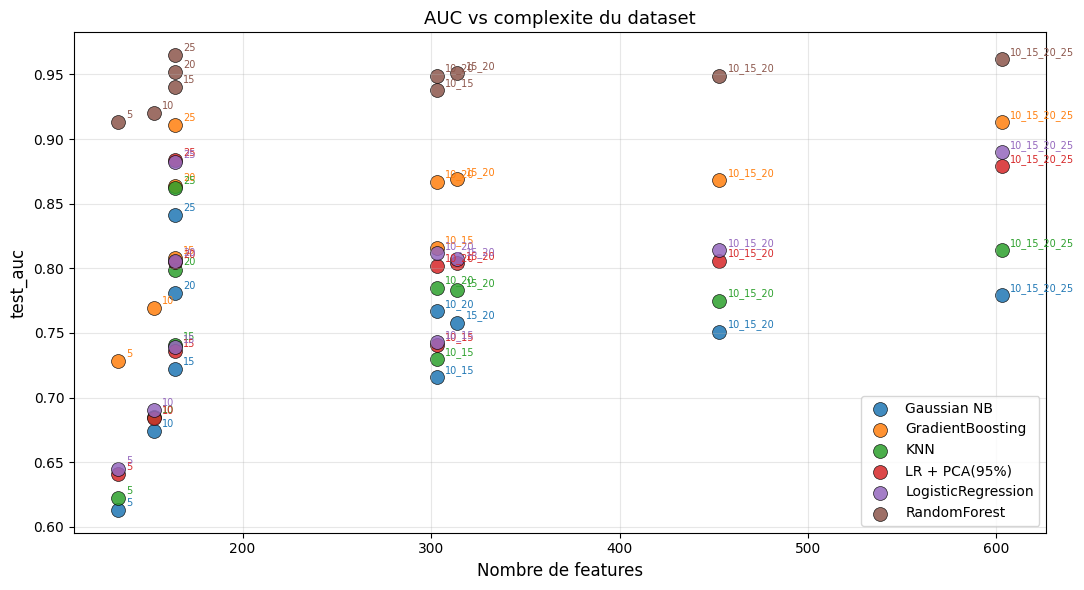

In [47]:
fig, ax = plt.subplots(figsize=(11, 6))
colors = plt.cm.tab10.colors

for i, (model_name, grp) in enumerate(results_df.groupby("model")):
    ax.scatter(grp["n_features"], grp["test_auc"],label=model_name,s=100,alpha=0.85,color=colors[i], edgecolors="black",linewidths=0.5)
    for _, row in grp.iterrows():
        ax.annotate(row["config"], (row["n_features"], row["test_auc"]),textcoords="offset points",xytext=(6, 3),fontsize=7,color=colors[i])

ax.set_xlabel("Nombre de features", fontsize=12)
ax.set_ylabel("test_auc", fontsize=12)
ax.set_title("AUC vs complexite du dataset", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
##  Visualisation PCA

Analyse en composantes principales sur la meilleure configuration (25 min).

Composantes pour 80% de variance : 56
Composantes pour 90% de variance : 79
Composantes pour 95% de variance : 97
Composantes pour 99% de variance : 124
Total features : 164


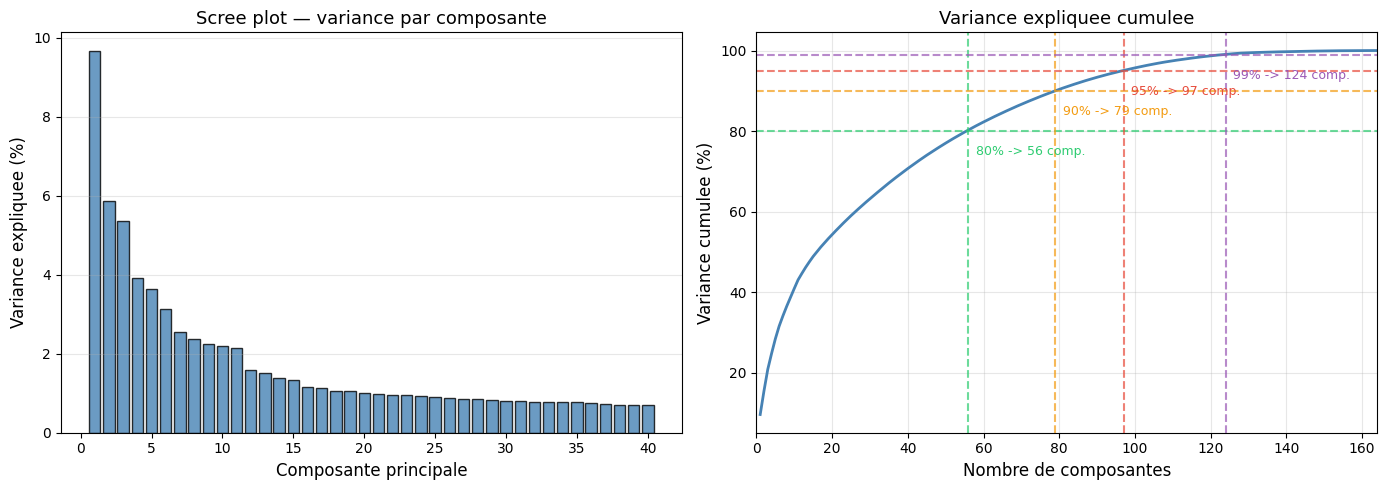

In [48]:
# Charger la config 25 min
csv_25 = next(
    (f for f in csv_files
     if f.replace("matchs_preprocessed_", "").replace(".csv", "") == "25"),
    csv_files[-1]
)
df_25 = pd.read_csv(csv_25, index_col=0)
feature_cols_25 = [c for c in df_25.select_dtypes(include="number").columns if c != "win"]
X_25 = df_25[feature_cols_25].copy()
y_25 = df_25["win"].astype(int).reset_index(drop=True)

imputer_25  = SimpleImputer(strategy="median")
scaler_25 = StandardScaler()
X_25_scaled = scaler_25.fit_transform(imputer_25.fit_transform(X_25))

pca_full= PCA(random_state=42)
pca_full.fit(X_25_scaled)

explained  = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

n_80=int(np.searchsorted(cumulative, 0.80)) + 1
n_90=int(np.searchsorted(cumulative, 0.90)) + 1
n_95=int(np.searchsorted(cumulative, 0.95)) + 1
n_99=int(np.searchsorted(cumulative, 0.99)) + 1

print(f"Composantes pour 80% de variance : {n_80}")
print(f"Composantes pour 90% de variance : {n_90}")
print(f"Composantes pour 95% de variance : {n_95}")
print(f"Composantes pour 99% de variance : {n_99}")
print(f"Total features : {X_25_scaled.shape[1]}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_show = 40
axes[0].bar(range(1, n_show + 1), explained[:n_show] * 100,color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_xlabel("Composante principale", fontsize=12)
axes[0].set_ylabel("Variance expliquee (%)", fontsize=12)
axes[0].set_title("Scree plot — variance par composante", fontsize=13)
axes[0].grid(axis="y", alpha=0.3)

axes[1].plot(range(1, len(cumulative) + 1), cumulative * 100, color="steelblue", linewidth=2)
for seuil, n, col in [(80, n_80, "#2ecc71"), (90, n_90, "#f39c12"), (95, n_95, "#e74c3c"), (99, n_99, "#9b59b6")]:
    axes[1].axhline(seuil, color=col, linestyle="--", alpha=0.7)
    axes[1].axvline(n,color=col, linestyle="--", alpha=0.7)
    axes[1].annotate(f"{seuil}% -> {n} comp.", xy=(n, seuil),xytext=(n + 2, seuil - 6), fontsize=9, color=col)
axes[1].set_xlabel("Nombre de composantes", fontsize=12)
axes[1].set_ylabel("Variance cumulee (%)", fontsize=12)
axes[1].set_title("Variance expliquee cumulee", fontsize=13)
axes[1].set_xlim(0, len(cumulative))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Projection 2D : PC1 vs PC2 colorée par victoire/défaite

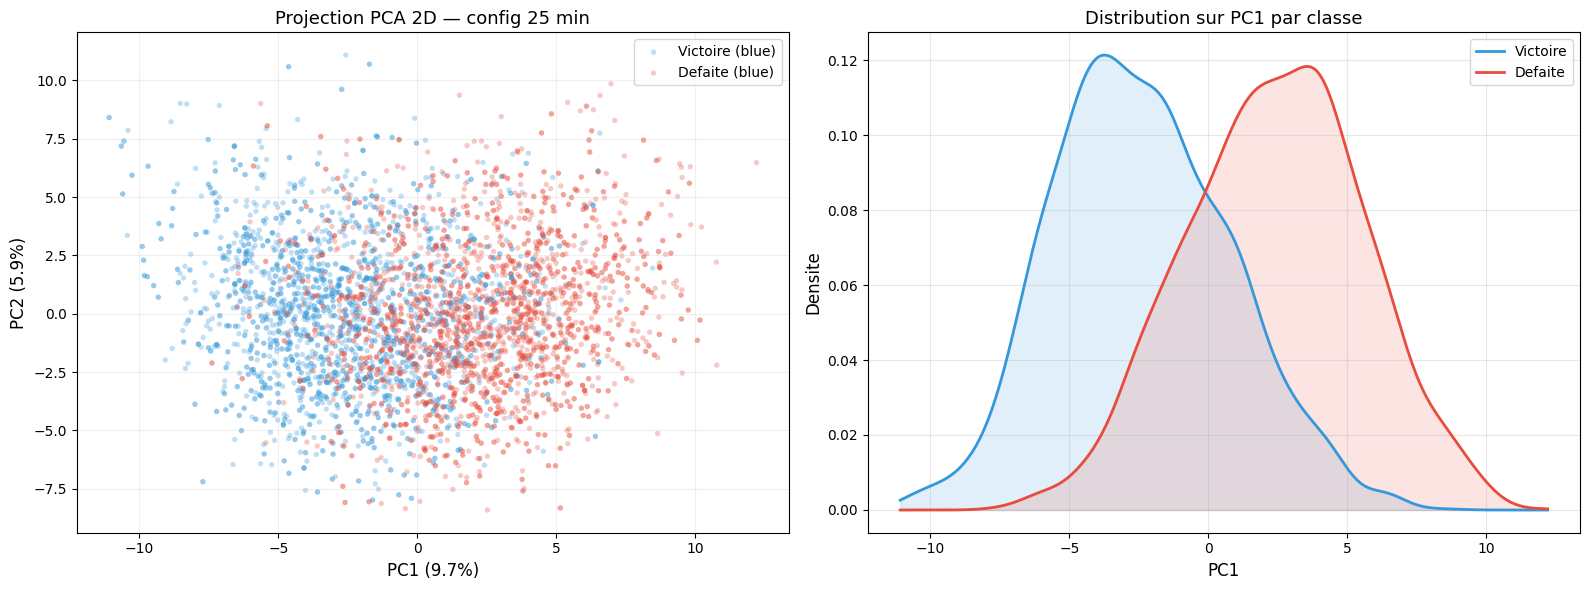

PC1 : 9.7%   PC2 : 5.9%   Total : 15.5%


In [49]:
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_25_scaled)
y_arr  = y_25.values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for label, name, color in [(1, "Victoire (blue)", "#3498db"), (0, "Defaite (blue)", "#e74c3c")]:
    mask = y_arr == label
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=name,alpha=0.3, s=15, edgecolors="none")
axes[0].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12)
axes[0].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12)
axes[0].set_title("Projection PCA 2D — config 25 min", fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.2)

for label, name, color in [(1, "Victoire", "#3498db"), (0, "Defaite", "#e74c3c")]:
    vals =X_2d[y_arr==label, 0]
    kde = gaussian_kde(vals)# lisse la distribution des scores en superposant une courbe gaussienne
    xs= np.linspace(X_2d[:, 0].min(), X_2d[:, 0].max(), 300)
    axes[1].plot(xs, kde(xs), color=color, linewidth=2, label=name)
    axes[1].fill_between(xs, kde(xs), alpha=0.15, color=color)

axes[1].set_xlabel("PC1", fontsize=12)
axes[1].set_ylabel("Densite", fontsize=12)
axes[1].set_title("Distribution sur PC1 par classe", fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

v1, v2 = pca_2d.explained_variance_ratio_
print(f"PC1 : {v1*100:.1f}%   PC2 : {v2*100:.1f}%   Total : {(v1+v2)*100:.1f}%")


---
## Clustering K-Means

Recherche de groupes naturels dans les données (sans label). On vérifie si les clusters se corrèlent avec la victoire.

k=2 silhouette=0.0619
k=3 silhouette=0.0364
k=4 silhouette=0.0304
k=5 silhouette=0.0252
k=6 silhouette=0.0243
k=7 silhouette=0.0206
k=8 silhouette=0.0223
k=9 silhouette=0.0212
k=10 silhouette=0.0194

Meilleur k : 2  (silhouette=0.0619)


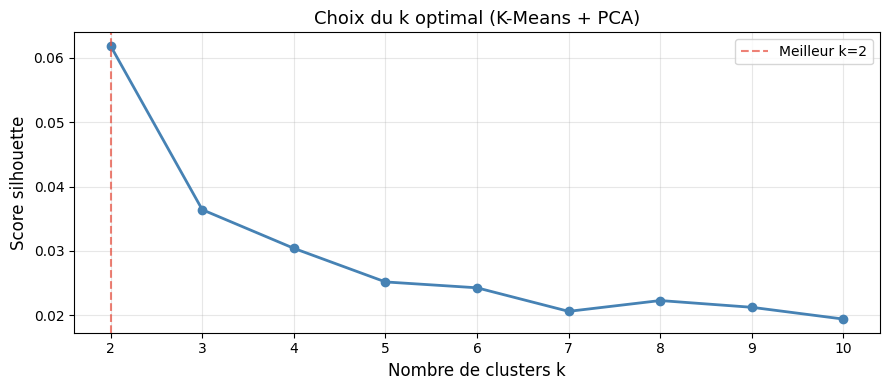

In [50]:
pca_cluster = PCA(n_components=n_95, random_state=42)
X_reduced =pca_cluster.fit_transform(X_25_scaled)

k_range=range(2, 11)
sil_scores=[]

for k in k_range:
    km= KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl= km.fit_predict(X_reduced)
    score =silhouette_score(X_reduced, lbl, sample_size=1000, random_state=42) #mesure si chaque point est bien dans son cluster Score entre -1 et 1 -> plus c'est proche de 1, mieux les clusters sont séparés
    sil_scores.append(score)
    print(f"k={k} silhouette={score:.4f}")

best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"\nMeilleur k : {best_k}  (silhouette={max(sil_scores):.4f})")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(k_range), sil_scores, marker="o", linewidth=2, color="steelblue")
ax.axvline(best_k, color="#e74c3c", linestyle="--", alpha=0.7, label=f"Meilleur k={best_k}")
ax.set_xlabel("Nombre de clusters k", fontsize=12)
ax.set_ylabel("Score silhouette", fontsize=12)
ax.set_title("Choix du k optimal (K-Means + PCA)", fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Visualisation des clusters et corrélation avec victoire/défaite

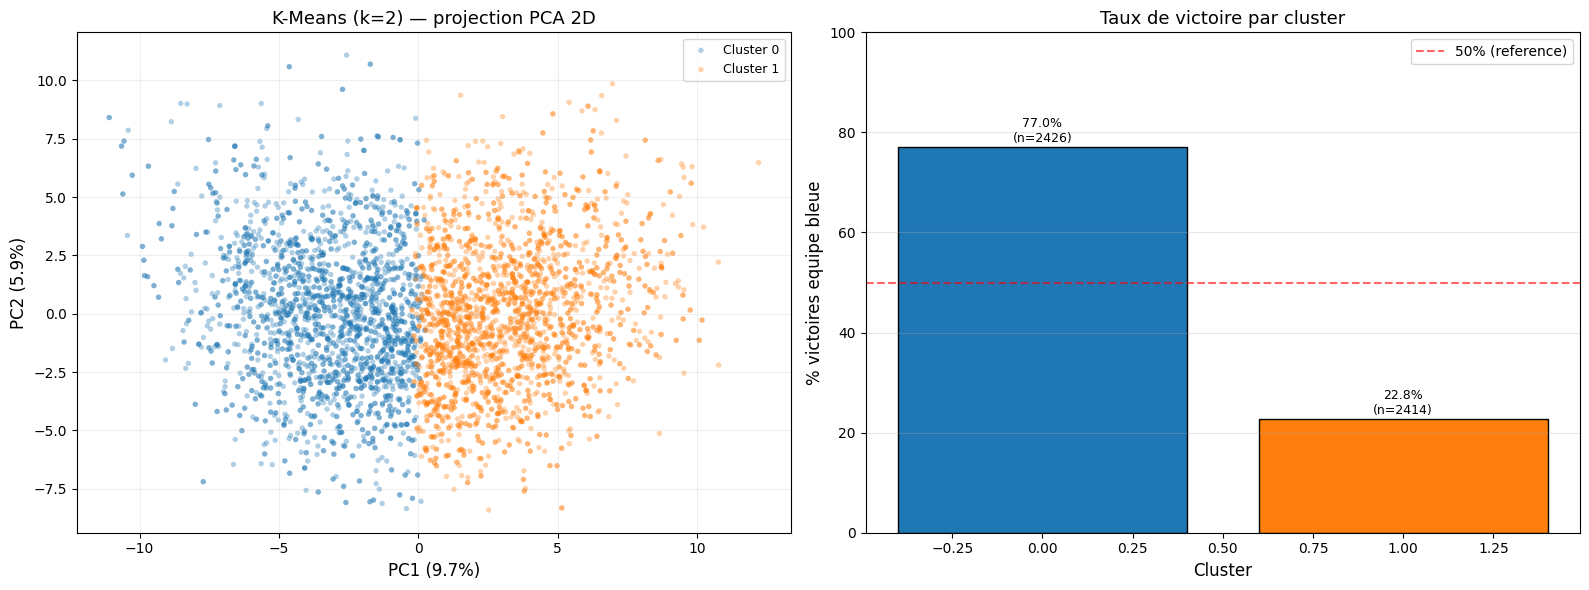


Taux de victoire par cluster :
 cluster  win_rate  count
       0  0.770404   2426
       1  0.227838   2414


In [51]:
km_best= KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels =km_best.fit_predict(X_reduced)

fig, axes =plt.subplots(1, 2, figsize=(16, 6))
palette= plt.cm.tab10.colors

for k in range(best_k):
    mask = cluster_labels == k
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1], c=[palette[k]],label=f"Cluster {k}", alpha=0.35, s=15, edgecolors="none")
axes[0].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12)
axes[0].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12)
axes[0].set_title(f"K-Means (k={best_k}) — projection PCA 2D", fontsize=13)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.2)

win_by_cluster=pd.DataFrame({"cluster": cluster_labels, "win": y_arr})
win_rate =win_by_cluster.groupby("cluster")["win"].agg(["mean", "count"]).reset_index()
win_rate.columns =["cluster", "win_rate", "count"]

bars = axes[1].bar(win_rate["cluster"], win_rate["win_rate"] * 100,color=[palette[int(k)] for k in win_rate["cluster"]], edgecolor="black")
axes[1].axhline(50, color="red", linestyle="--", alpha=0.6, label="50% (reference)")
axes[1].set_xlabel("Cluster", fontsize=12)
axes[1].set_ylabel("% victoires equipe bleue", fontsize=12)
axes[1].set_title("Taux de victoire par cluster", fontsize=13)
axes[1].set_ylim(0, 100)
axes[1].legend()
for bar, row in zip(bars, win_rate.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{row.win_rate*100:.1f}%\n(n={row.count})", ha="center", fontsize=9)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTaux de victoire par cluster :")
print(win_rate.to_string(index=False))


---
## Visualisation des modèles

Learning curves, calibration et coefficients LR sur la config 25 min.

### Learning Curves (biais vs variance)

Montrent si un modèle bénéficierait de plus de données ou s'il overfitte.

Learning curve : RandomForest...
Learning curve : LogisticRegression...
Learning curve : GradientBoosting...


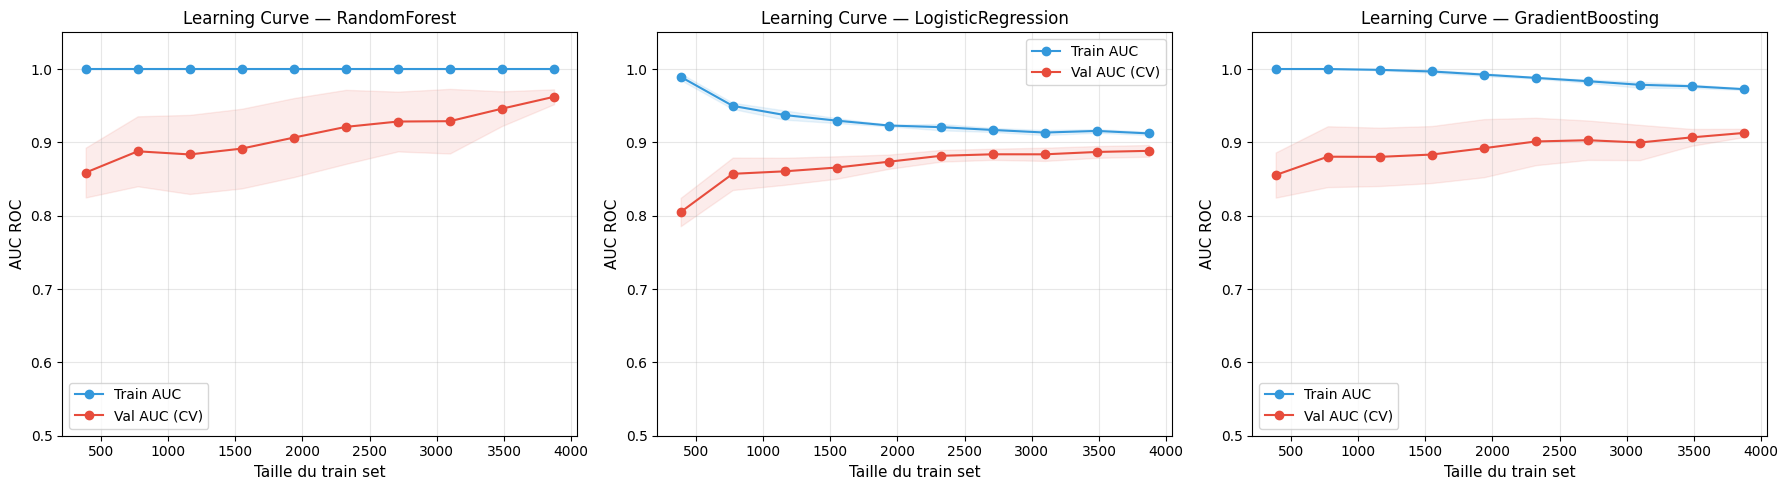

In [52]:
# csv_25 : config 25 min (redéfini localement pour éviter les dépendances inter-cellules)
csv_25_lc = next(
    (f for f in csv_files
     if f.replace("matchs_preprocessed_", "").replace(".csv", "") == "25"),
    csv_files[-1]
)
df_lc = pd.read_csv(csv_25_lc, index_col=0)
fc_lc = [c for c in df_lc.select_dtypes(include="number").columns if c != "win"]
X_lc  = df_lc[fc_lc]
y_lc  = df_lc["win"].astype(int)

models_lc = {
    "RandomForest"      : make_pipeline(RandomForestClassifier(n_estimators=100, random_state=42)),
    "LogisticRegression": make_pipeline(LogisticRegression(max_iter=1000)),
    "GradientBoosting"  : make_pipeline(GradientBoostingClassifier(random_state=42)),
}

fig, axes = plt.subplots(1, len(models_lc), figsize=(18, 5))

for ax, (name, pipe) in zip(axes, models_lc.items()):
    print(f"Learning curve : {name}...")
    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X_lc, y_lc,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5, scoring="roc_auc",
        n_jobs=1  # n_jobs=-1 cause des crashs multiprocessing sur Windows/Jupyter
    )
    tm, ts = train_scores.mean(axis=1), train_scores.std(axis=1)
    vm, vs = val_scores.mean(axis=1),   val_scores.std(axis=1)

    ax.plot(train_sizes, tm, "o-", color="#3498db", label="Train AUC")
    ax.fill_between(train_sizes, tm - ts, tm + ts, alpha=0.1, color="#3498db")
    ax.plot(train_sizes, vm, "o-", color="#e74c3c", label="Val AUC (CV)")
    ax.fill_between(train_sizes, vm - vs, vm + vs, alpha=0.1, color="#e74c3c")

    ax.set_title(f"Learning Curve — {name}", fontsize=12)
    ax.set_xlabel("Taille du train set", fontsize=11)
    ax.set_ylabel("AUC ROC", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.5, 1.05)

plt.tight_layout()
plt.show()


### Courbes de calibration (reliability diagram)

Si le modèle prédit 70% de proba de victoire, la vraie fréquence doit être ~70%.

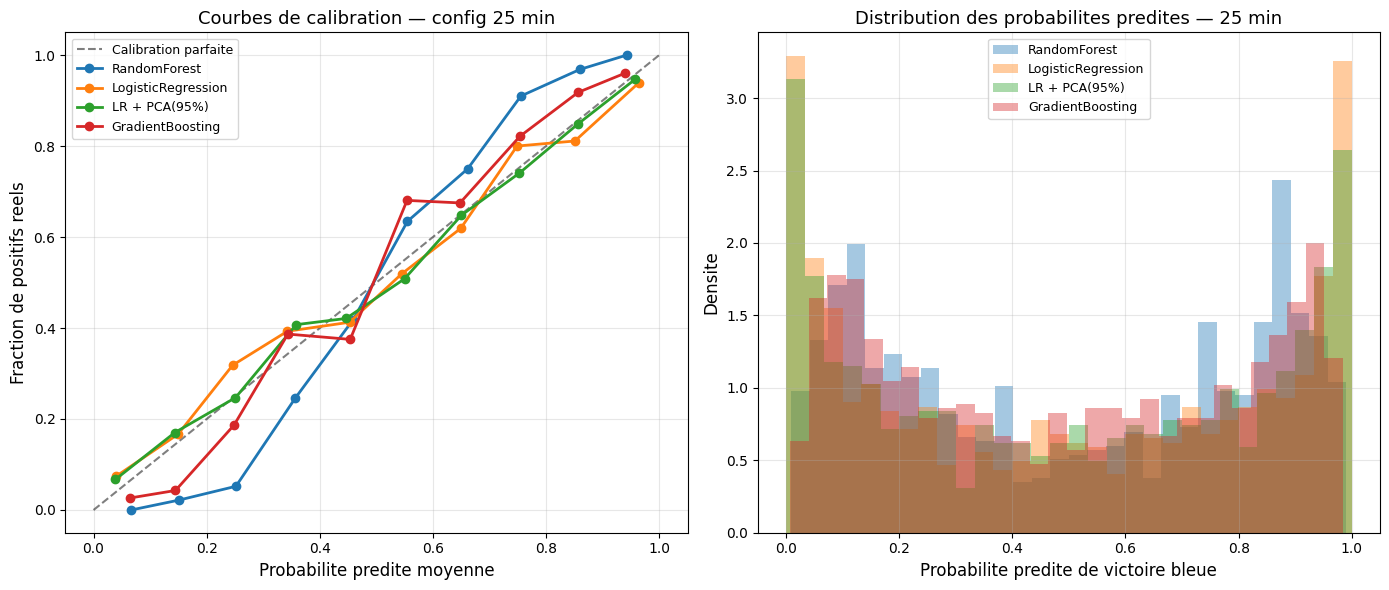

In [53]:
models_calib = ["RandomForest", "LogisticRegression", "LR + PCA(95%)", "GradientBoosting"]
X_t25, y_t25 = test_sets.get("25", (None, None))

if X_t25 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Calibration parfaite")
    for name in models_calib:
        if name not in fitted_pipes.get("25", {}):
            continue
        pipe = fitted_pipes["25"][name]
        y_prob = pipe.predict_proba(X_t25)[:, 1]
        frac_pos, mean_pred = calibration_curve(y_t25, y_prob, n_bins=10)
        axes[0].plot(mean_pred, frac_pos, marker="o", linewidth=2, label=name)

    axes[0].set_xlabel("Probabilite predite moyenne", fontsize=12)
    axes[0].set_ylabel("Fraction de positifs reels", fontsize=12)
    axes[0].set_title("Courbes de calibration — config 25 min", fontsize=13)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    for name in models_calib:
        if name not in fitted_pipes.get("25", {}):
            continue
        pipe = fitted_pipes["25"][name]
        y_prob = pipe.predict_proba(X_t25)[:, 1]
        axes[1].hist(y_prob, bins=30, alpha=0.4, label=name, density=True)

    axes[1].set_xlabel("Probabilite predite de victoire bleue", fontsize=12)
    axes[1].set_ylabel("Densite", fontsize=12)
    axes[1].set_title("Distribution des probabilites predites — 25 min", fontsize=13)
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


### Coefficients Logistic Regression

Coefficients positifs → favorisent victoire bleue. Négatifs → favorisent défaite.

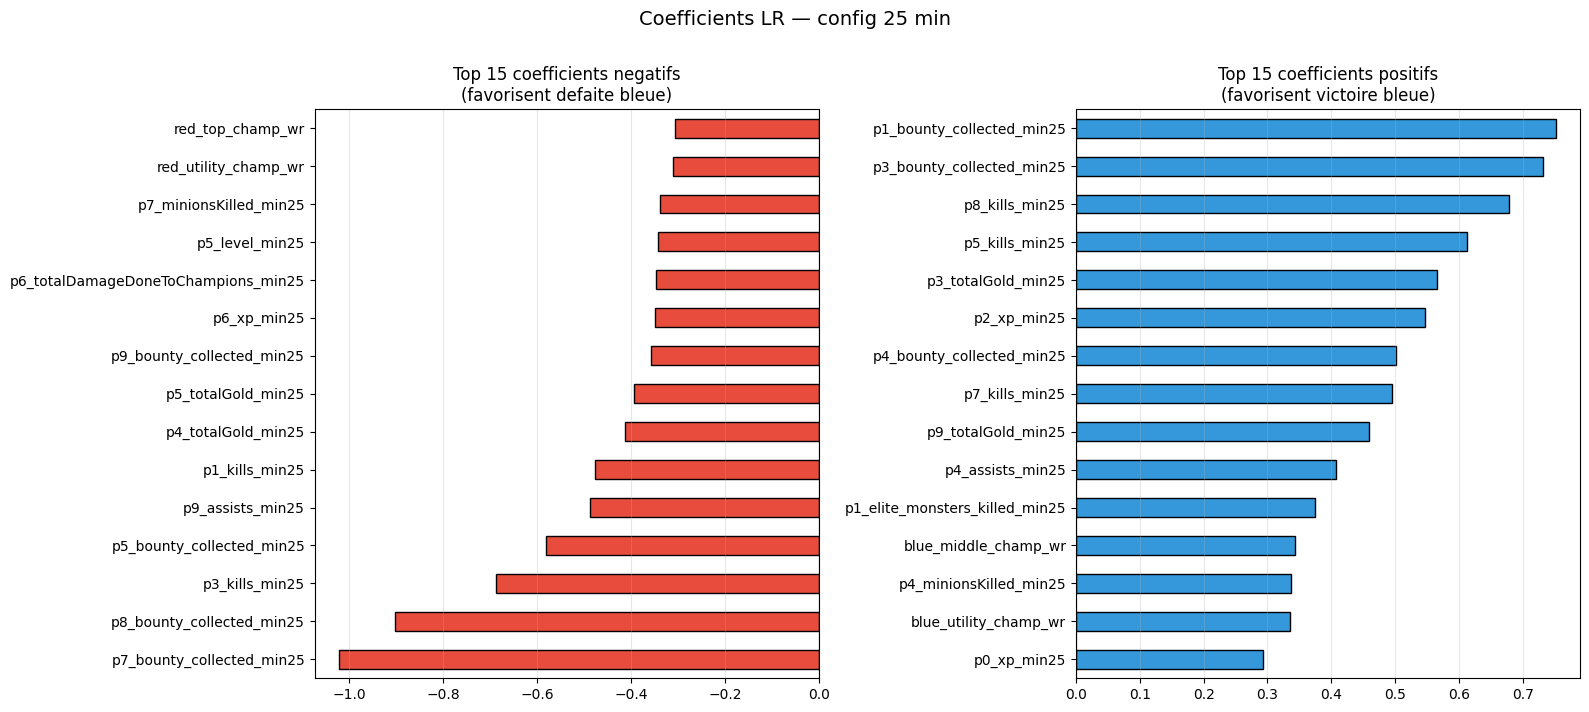

In [54]:
if "25" in fitted_pipes and "LogisticRegression" in fitted_pipes["25"]:
    pipe_lr  = fitted_pipes["25"]["LogisticRegression"]
    lr_model = pipe_lr.named_steps["model"]
    imputer = pipe_lr.named_steps["imputer"]
    X_t, _ = test_sets["25"]

    if hasattr(imputer,"get_feature_names_out"):
        feat_names = list(imputer.get_feature_names_out())
    else:
        mask = ~np.isnan(imputer.statistics_)
        feat_names = np.array(X_t.columns.tolist())[mask].tolist()

    coefs= pd.Series(lr_model.coef_[0], index=feat_names).sort_values()
    n_show = 15
    top_neg = coefs.head(n_show).sort_values()
    top_pos = coefs.tail(n_show).sort_values()

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    top_neg.plot(kind="barh", ax=axes[0], color="#e74c3c", edgecolor="black")
    axes[0].set_title(f"Top {n_show} coefficients negatifs\n(favorisent defaite bleue)", fontsize=12)
    axes[0].axvline(0, color="black", linewidth=0.8)
    axes[0].grid(axis="x", alpha=0.3)

    top_pos.plot(kind="barh", ax=axes[1], color="#3498db", edgecolor="black")
    axes[1].set_title(f"Top {n_show} coefficients positifs\n(favorisent victoire bleue)", fontsize=12)
    axes[1].axvline(0, color="black", linewidth=0.8)
    axes[1].grid(axis="x", alpha=0.3)

    plt.suptitle("Coefficients LR — config 25 min", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
